In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import thư viện cần dùng

1. Tải dữ liệu: Tải used_car.csv từ Google Drive:

In [2]:
df = pd.read_csv('used_cars.csv')
# đọc file csv đề bài cho
df.head()
# xem 5 dòng đầu tiên data frame

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


2. Đọc và in thông tin dữ liệu: Dùng pandas đọc CSV và in thông tin cơ bản
(DataFrame.info(), DataFrame.columns, ...).

In [3]:
df.info()
# thông tin data frame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [4]:
df.shape
# đọc số dòng, số cột

(4009, 12)

In [5]:
df.isnull().sum()
# đọc các giá trị NaN của từng cột

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [6]:
df.columns
# tên từng cột

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

3. Tiền xử lý dữ liệu:

• Chọn input: model_year; output: price.

• Chuyển price từ string sang int.

• Dùng matplotlib vẽ scatter giữa x = model_year và y = price (tham khảo code ngày 21).

• Chia dữ liệu: 80% train, 20% test.

In [7]:
df['price']= df['price'].apply(lambda x:x[1:])
# lược bỏ kí hiệu dollars
df['price']= df['price'].apply(lambda x:x.replace(',',''))
# xóa kí dấu ','
df['price']= df['price'].apply(lambda x:int(x))
# chuyển từ string sang int

In [8]:
df.head()
# xem lại 5 dòng đầu tiên của Data Frame sau khi thay đổi

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999


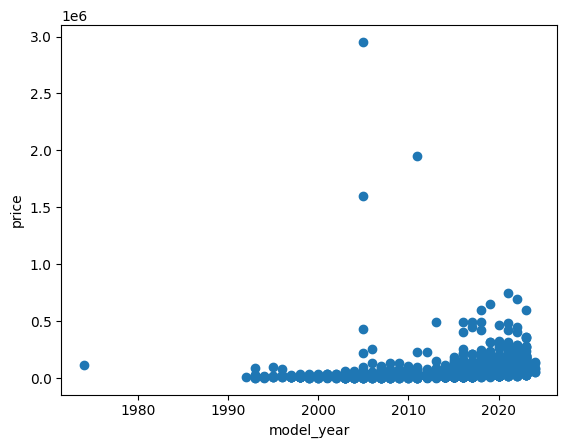

In [9]:
plt.scatter(df['model_year'],df['price'])
plt.xlabel('model_year')
plt.ylabel('price')
plt.show()
# vẽ scatter bằng matplotlib

In [10]:
number_training = int(len(df)*0.8)
x_train = df['model_year'][:number_training]
y_train = df['price'][:number_training]
x_test = df['model_year'][number_training:]
y_test = df['price'][number_training:]
# chia 80% data để train còn 20% để test

4. Khai báo mô hình hồi quy tuyến tính: Sử dụng mô hình từ solution ngày 21. Đặt tên tiếng Anh cho hàm/biến: fit(), predict(), loss_history, weights.

In [11]:
# tạo hàm tính y dự đoán
def y_predict(x,w_ktao,b_ktao):
    y_hat = w_ktao*x+b_ktao
    return y_hat

# tạo hàm tính hàm Loss
def loss(y,y_hat):
    loss_i = (y_hat-y)**2
    return loss_i

# tạo hàm tính đạo hàm L theo w, theo b
def dao_ham(x,y,y_hat):
    l_theo_w = 2*x*(y_hat - y)
    l_theo_b = 2*(y_hat - y)
    return l_theo_w, l_theo_b

# tạo hàm tính w,b mới
def w_new_and_b_new(w_old,b_old,learn_rate,l_theo_w,l_theo_b):
    w_new = w_old - learn_rate*l_theo_w
    b_new = b_old - learn_rate*l_theo_b
    return w_new,b_new

# hàm hồi quy tuyến tính
def linear_regression(w_ktao,b_ktao,x_train,y_train,learn_rate,number_training,weight_lst,loss_lst,epochs,total_loss):
    for epoch in range (epochs):
        for i in range(number_training):
            y_hat = y_predict(x_train[i],w_ktao,b_ktao)
            loss_i = loss(y_train[i],y_hat)
            loss_lst.append(loss_i)
            l_theo_w, l_theo_b = dao_ham(x_train[i],y_train[i],y_hat)
            w_ktao,b_ktao = w_new_and_b_new(w_ktao,b_ktao,learn_rate,l_theo_w,l_theo_b)
            weight_lst.append(w_ktao)
            total_loss += loss_i 
            print(f"Epoch {epoch} : Loss {loss_i}")
        # print(f"Epoch {epoch} : Loss {total_loss}")
        # total_loss = 0
    return w_ktao,b_ktao

5. Training: Huấn luyện mô hình và quan sát loss. Nếu loss lớn dẫn tới NaN, hãy normalize input và output rồi huấn luyện lại.

In [12]:
w_ktao = 10
b_ktao = 5
learn_rate = 0.01
epochs = 5
loss_lst = []
weight_lst = []
total_loss = 0
linear_regression(w_ktao,b_ktao,x_train,y_train,learn_rate,number_training,weight_lst,loss_lst,epochs,total_loss)


Epoch 0 : Loss 96727225
Epoch 0 : Loss 6.40395718430267e+17
Epoch 0 : Loss 4.277528579530795e+27
Epoch 0 : Loss 2.840239123492754e+37
Epoch 0 : Loss 1.8840270835575442e+47
Epoch 0 : Loss 1.250980084363041e+57
Epoch 0 : Loss 8.273566594324203e+66
Epoch 0 : Loss 5.390738585284377e+76
Epoch 0 : Loss 3.5263420489351996e+86
Epoch 0 : Loss 2.3507658491456077e+96
Epoch 0 : Loss 1.5670912993781717e+106
Epoch 0 : Loss 1.043636201738889e+116
Epoch 0 : Loss 6.950306399852506e+125
Epoch 0 : Loss 4.642462999254181e+135
Epoch 0 : Loss 3.0978691802454435e+145
Epoch 0 : Loss 2.048815844693945e+155
Epoch 0 : Loss 1.356352549700752e+165
Epoch 0 : Loss 8.979297004972759e+174
Epoch 0 : Loss 5.839037632346686e+184
Epoch 0 : Loss 3.8158814865559415e+194
Epoch 0 : Loss 2.543773898738078e+204
Epoch 0 : Loss 1.665635075229493e+214
Epoch 0 : Loss 1.087406530421756e+224
Epoch 0 : Loss 7.26333377029544e+233
Epoch 0 : Loss 4.856350078278619e+243
Epoch 0 : Loss 3.2438031149694454e+253
Epoch 0 : Loss 2.1559933974807

C:\Users\ldraw\AppData\Local\Temp\ipykernel_6128\4226533780.py:8: RuntimeWarning: overflow encountered in scalar power
  loss_i = (y_hat-y)**2
C:\Users\ldraw\AppData\Local\Temp\ipykernel_6128\4226533780.py:3: RuntimeWarning: overflow encountered in scalar multiply
  y_hat = w_ktao*x+b_ktao
C:\Users\ldraw\AppData\Local\Temp\ipykernel_6128\4226533780.py:19: RuntimeWarning: invalid value encountered in scalar subtract
  w_new = w_old - learn_rate*l_theo_w
C:\Users\ldraw\AppData\Local\Temp\ipykernel_6128\4226533780.py:20: RuntimeWarning: invalid value encountered in scalar subtract
  b_new = b_old - learn_rate*l_theo_b


Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Loss nan
Epoch 2 : Lo

(np.float64(nan), np.float64(nan))

In [13]:
# chuẩn hóa dữ liệu về cùng 1 quy chuẩn từ 0 tới 1
max_model_year = max(df['model_year'])
min_model_year = min(df['model_year'])
df['model_year'] = df['model_year'].apply(lambda x:(x - min_model_year)/(max_model_year-min_model_year))
max_price = max(df['price'])
min_price = min(df['price'])
df['price'] = df['price'].apply(lambda x:(x - min_price)/(max_price-min_price))
learn_rate =0.001
# chỉnh learn rate thấp hơn 10 lần -> học chậm hơn 10 lần
number_training = int(len(df)*0.8)
x_train = df['model_year'][:number_training]
y_train = df['price'][:number_training]
x_test = df['model_year'][number_training:]
y_test = df['price'][number_training:]
clean_loss_lst = []
clean_weight_lst = []
w_model,b_model = linear_regression(w_ktao,b_ktao,x_train,y_train,learn_rate,number_training,clean_weight_lst,clean_loss_lst,epochs,0)

Epoch 0 : Loss 163.7680316088893
Epoch 0 : Loss 205.73436722773926
Epoch 0 : Loss 209.75292589649334
Epoch 0 : Loss 170.32589114784273
Epoch 0 : Loss 201.3306041667059
Epoch 0 : Loss 173.04805040397113
Epoch 0 : Loss 176.9302405564777
Epoch 0 : Loss 102.35280660433976
Epoch 0 : Loss 196.21298315476838
Epoch 0 : Loss 189.04719657251397
Epoch 0 : Loss 193.0078207787688
Epoch 0 : Loss 179.91247670056163
Epoch 0 : Loss 190.37864495366176
Epoch 0 : Loss 194.2340429583463
Epoch 0 : Loss 182.2851337392802
Epoch 0 : Loss 146.5960499628754
Epoch 0 : Loss 183.16600083744098
Epoch 0 : Loss 144.63169323754022
Epoch 0 : Loss 101.4818515052133
Epoch 0 : Loss 166.34426618852385
Epoch 0 : Loss 190.6907466401454
Epoch 0 : Loss 88.2807134553738
Epoch 0 : Loss 173.27430282010613
Epoch 0 : Loss 187.0607522979648
Epoch 0 : Loss 175.41108769341457
Epoch 0 : Loss 179.36562411703798
Epoch 0 : Loss 149.29827674941956
Epoch 0 : Loss 171.61108816991404
Epoch 0 : Loss 142.54020937245767
Epoch 0 : Loss 150.6559355

6. In ra hàm loss: Sau khi huấn luyện, plot biểu đồ loss (tham khảo code ngày 21).

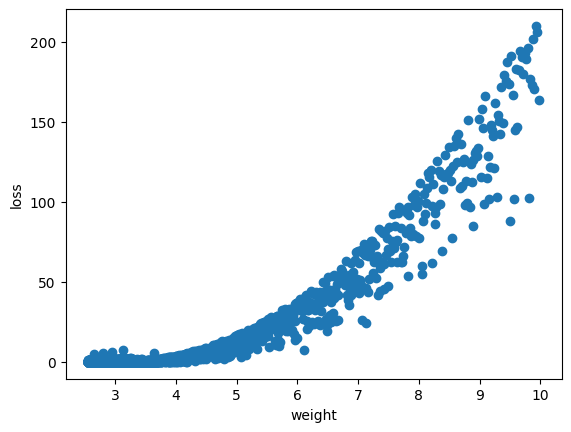

In [14]:
plt.scatter(clean_weight_lst,clean_loss_lst)
plt.xlabel('weight')
plt.ylabel('loss')
plt.show()

7. Thực hiện dự đoán: Dùng mô hình đã huấn luyện để predict giá theo model_year. In các weights của mô hình.

In [15]:
predict_price = w_model*x_test[number_training]+b_model
print(f"Giá được chuẩn hóa: {predict_price}")
print(f"Các weight của mô hình: {weight_lst}")
print(f"Giá dự đoán là: {predict_price*(max_price-min_price)+min_price}")

Giá được chuẩn hóa: 0.34641833433551605
Các weight của mô hình: [np.float64(-395947.10000000003), np.float64(32345599344.936005), np.float64(-2644857607268591.0), np.float64(2.1477174742586183e+20), np.float64(-1.7544240153034771e+25), np.float64(1.42606847192479e+30), np.float64(-1.1603177601861454e+35), np.float64(9.291713214657049e+39), np.float64(-7.590199842622232e+44), np.float64(6.194135902857374e+49), np.float64(-5.059855826321976e+54), np.float64(4.125110203619776e+59), np.float64(-3.3697134237738644e+64), np.float64(2.755370860678842e+69), np.float64(-2.248576048803273e+74), np.float64(1.8222999942169302e+79), np.float64(-1.488597505044376e+84), np.float64(1.2063951432495653e+89), np.float64(-9.680018105837127e+93), np.float64(7.883939160887979e+98), np.float64(-6.4529726713368306e+103), np.float64(5.16231488326415e+108), np.float64(-4.21281134957313e+113), np.float64(3.4481692396314355e+118), np.float64(-2.816734970717538e+123), np.float64(2.3032075682798645e+128), np.float6

8. Visualize đường thẳng dự đoán: Vẽ scatter model_year vs price trên test set, sau đó chồng đường hồi quy tuyến tính từ mô hình để thể hiện xu hướng dự đoán.

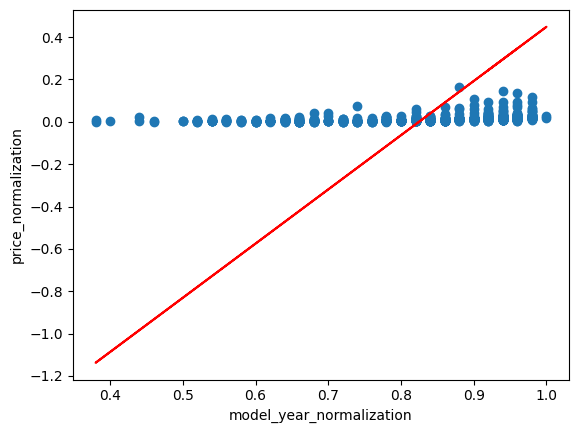

In [16]:
def my_func(x):
    return x*w_model+b_model
# tạo hàm model sau khi train xong
mymodel = list(map(my_func, x_test))
# tạo list y dự đoán 
plt.scatter(x_test,y_test)
plt.xlabel('model_year_normalization')
plt.ylabel('price_normalization')
plt.plot(x_test,mymodel,color = 'red')
plt.show()